In [64]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [9]:
def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
        """Load and combine multiple experiment CSVs."""
        dfs = []
        for path in csv_paths:
            df = pd.read_csv(path, index_col=0)
            df['source_file'] = Path(path).parent.name  # track which experiment it came from
            dfs.append(df)

            combined = pd.concat(dfs, ignore_index=True)
                
        return combined

In [22]:
import matplotlib.pyplot as plt

def plot_gap_vs_intervals(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

    # Unique gap sizes
    gap_sizes = sorted(df['gap_size_range'].unique())
    
    for g in gap_sizes:
        subset = df[df['gap_size_range'] == g]
        
        x = subset['num_intervals']
        y_time = subset['sum_time_mean']
        y_cov = subset['result_coverage_mean']
        yerr_time = subset['sum_time_std']

        ax1.errorbar(x, y_time, yerr=yerr_time, fmt='o-', label=f'gap={g}')
        ax2.plot(x, y_cov, 'o-', label=f'gap={g}')

    ax1.set_xlabel("Num Intervals")
    ax1.set_ylabel("Sum Time (ms)")
    ax1.set_title("Time vs Num Intervals")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Num Intervals")
    ax2.set_ylabel("Result Coverage")
    ax2.set_title("Coverage vs Num Intervals")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [65]:
# plot_gap_vs_intervals(df)

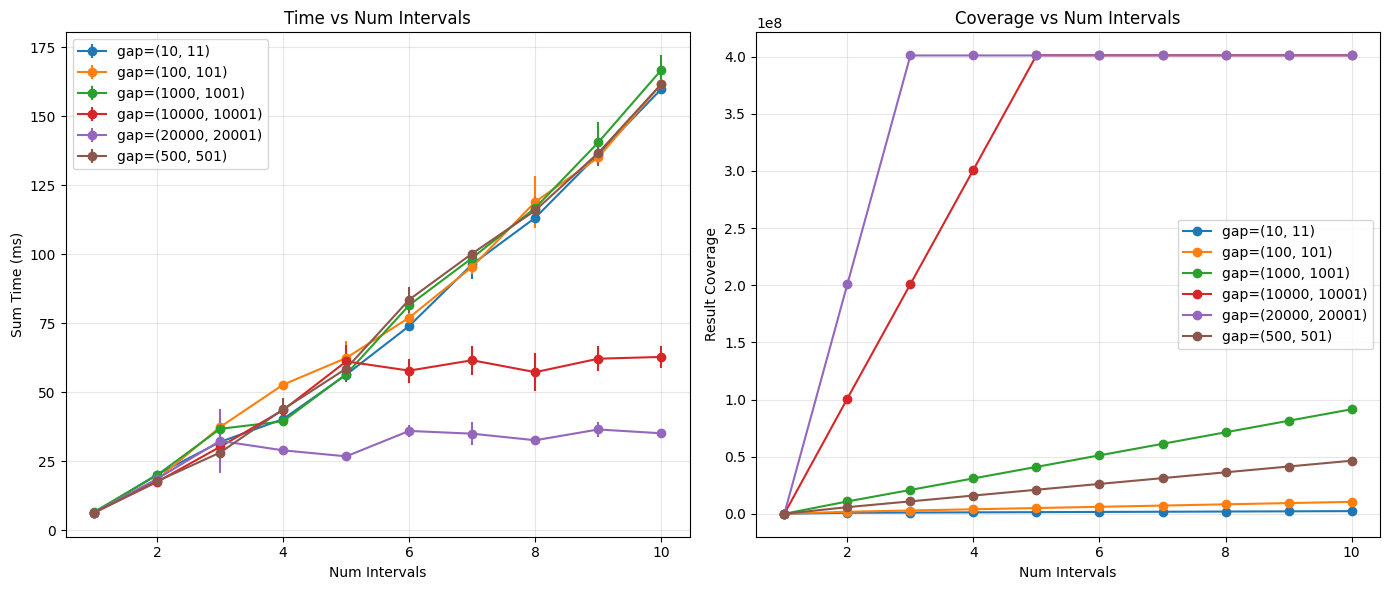

In [24]:
paths = ['data/results/2276863277/ni_gap_10k/ni_gap_red15_10_sweep/results_sd2276863277.csv']
df = load_all_csvs(paths)
plot_gap_vs_intervals(df)

In [101]:
paths2 = ['data/results/2277254639/ni_gap_10k/ni_gap_red15_10_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red10_5_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red4_2_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red9_3_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red5_2_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red3_1_sweep//results_sd2277254639.csv', 'data/results/2277254639/ni_gap_10k/ni_gap_red1_1_sweep//results_sd2277254639.csv']
df = load_all_csvs(paths2)
# plot_gap_vs_intervals(df2)
df = df.sort_values('gap_size_range')

df['gap_size_range'] = df['gap_size_range'].apply(ast.literal_eval)

gap_size_range   (10, 11)  (100, 101)  (500, 501)  (1000, 1001)  \
num_intervals                                                     
1                6.390600    6.556114    6.448771      6.403514   
2               11.066943   10.909371   10.718343     11.240600   
3               15.192543   16.088714   15.009086     15.084286   
4               18.395286   19.030743   17.315200     19.761857   
5               22.179000   21.698400   22.077914     22.404171   
6               26.388600   27.211400   27.627286     26.754686   
7               30.696857   30.300143   31.352314     32.314943   
8               36.009429   35.537371   35.175486     36.016257   
9               40.293543   43.450486   41.665171     41.219857   
10              45.995629   47.912371   47.983314     46.225857   

gap_size_range  (10000, 10001)  (20000, 20001)  
num_intervals                                   
1                     6.491143        6.337971  
2                    10.509886       10.396971  

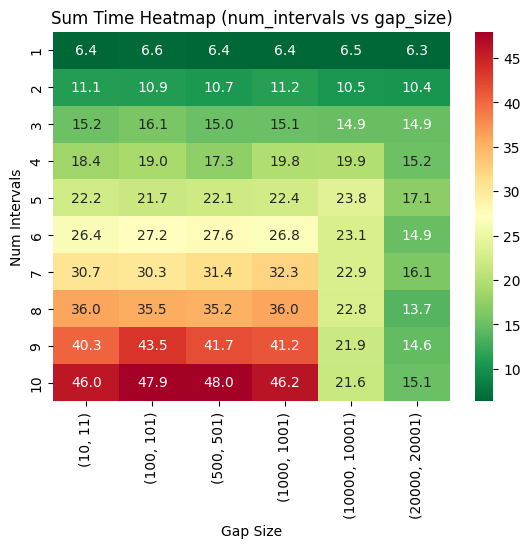

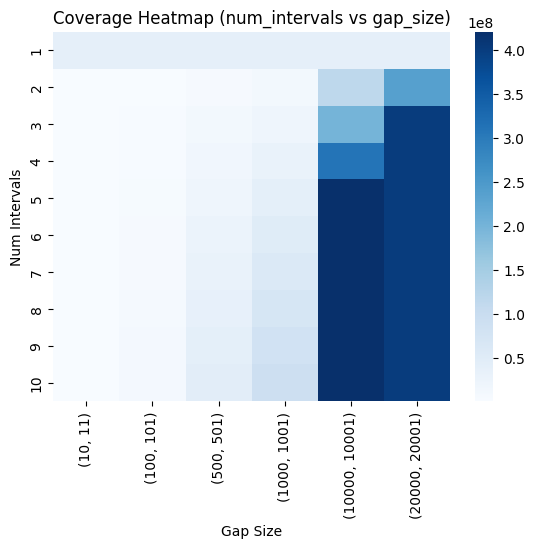

In [102]:
import seaborn as sns

# Time heatmap
time_pivot = df.pivot_table(values='sum_time_mean', index='num_intervals', columns='gap_size_range')
time_pivot.sort_index(axis=0)
print(time_pivot)

sns.heatmap(time_pivot, annot=True, fmt=".1f", cmap='RdYlGn_r')
plt.title("Sum Time Heatmap (num_intervals vs gap_size)")
plt.xlabel("Gap Size")
plt.ylabel("Num Intervals")
plt.show()

# Coverage heatmap
cov_pivot = df.pivot_table(values='result_coverage_mean', index='num_intervals', columns='gap_size_range')
cov_pivot.sort_index(axis=0)
sns.heatmap(cov_pivot, fmt=".2f", cmap='Blues')
plt.title("Coverage Heatmap (num_intervals vs gap_size)")
plt.xlabel("Gap Size")
plt.ylabel("Num Intervals")
plt.show()